# XPCS hysteresis: alternating phase retrieval and physical projection

Run `00_preprocess_263.ipynb` first. Every acquisition point is a separate magnetic state. Joint projections couple states through shared complex transmission and one complex magnetic response at the measured energy. The beginning/end saturation anchors set the **relative** magnetization scale; they are not zero magnetic signal. This is single-helicity state diversity, not a synthetic helicity sum.

The existing universal engine alternates retrieval blocks with joint physical projections. Warmup and final fields are retained. The primary mode carries the magnetic model; optional extra modes describe incoherent contributions; mode 2 can be shared or vary independently across states. Start with full coherence; partial coherence can be enabled after checking geometry and warmup.

Saturation-normalized magnetization is conditional on correct saturation, support, focus, phase alignment, stable illumination and the assumed uniform relative thickness. It is not an absolute magnetization in A/m. Forced endpoints and model clipping are not evidence of quantitative accuracy. Post-hoc, unclipped endpoint estimates provide an additional diagnostic; their endpoints are calibration too.

The focused primary exit wave is `psi_s = psi_charge * exp(q_magnetic * t * m_s)`, with **one common complex charge exit wave** for all states, including both saturated anchors. Illumination and charge are shared model components; their physical constraints apply only inside the object-hole aperture where thickness is nonzero. Reference holes and the exterior are left unchanged by the primary physical projection. With `MODES=[1,2]`, set `MODE_2_COMMON=True` for one common complex second-mode field across all states, or `False` to let it vary independently by state. This setting has no effect with `MODES=[1]`. Independent detector/support steps are followed by full joint projection; the final output stays on these constraints, so its intensity residual must be inspected rather than forced to zero. Warmup starts subsequent states from the reference reconstruction to reduce independent phase-gauge drift.

Set `CLIP_MAGNETIZATION=False` to allow fitted magnetization outside [-1, 1]. Saturation anchors remain fixed to their assigned signs.


In [ ]:
from pathlib import Path
import sys, json
import numpy as np
import h5py
import matplotlib.pyplot as plt
HERE = Path.cwd()
if HERE.name != "2601_XPCS": HERE = HERE / "2601_XPCS"
if not (HERE / "reconstruction_inputs.py").is_file(): raise FileNotFoundError("Run from repository root or 2601_XPCS")
sys.path.insert(0, str(HERE)); sys.path.insert(0, str(HERE.parent))
import reconstruction_inputs as inputs

from library import phase_retrieval_universal as universal
from library import phase_retrieval_geometry as geometry
from library import fthcore as fth
from library.retrieval_progress import retrieval_progress
CACHE = HERE / "processed/preprocessed_263.h5"
OUTPUT = HERE / "processed/physical_hysteresis_263.h5"
FIGURES = OUTPUT.with_suffix("")
STATE_STRIDE = 1
POINT_INDICES = list(np.arange(8,38)) #None  # Explicit cache acquisition indices, or None for stride.
# Explicit scan/point anchors; add only states independently known to saturate.
SATURATED_POINTS = {(263,8 ): +1.,(263,9 ): +1.,(263,10 ): +1.,(263,11 ): +1.,
                    (263,36): -1.,(263,37): -1.,(263,38): -1.,
                    }
MODES = [1,2]  # Use [1] for one mode or [1,2] for an enlarged second-mode support.
MODE_2_COMMON = True  # True: shared across states; False: independent per state.
WARMUP_ITERATIONS = [300,80]
OUTER_ITERATIONS = 10#10
INNER_ITERATIONS = 80
PHYSICAL_ITERATIONS = 1#20
CLIP_MAGNETIZATION = True  # False allows values outside [-1, 1]; saturation anchors stay fixed.
PROJECTION_RELAXATION = 0.45  # Enforce one charge wave and saturated magnetization at each joint boundary.
USE_PARTIAL_COHERENCE = False
FOCUS_PROP_UM = 0.  # Tune from reconstructed reference images; no ajajas value assumed.
FOCUS_PHASE_RAD = 0.
OBSERVATION_WORKERS = 1
FFT_WORKERS = 1
# Coordinates on the prepared object grid. None chooses three interior locations.
ROI_CENTERS = None
ROI_RADIUS = 3



In [24]:
with h5py.File(CACHE) as h:
    config=json.loads(h.attrs['config_json'])
    all_labels=h['state_labels'].asstr()[:].tolist()
    keys=list(zip(h['scan'][()].tolist(),h['point'][()].tolist()))
    if not isinstance(STATE_STRIDE,int) or STATE_STRIDE < 1: raise ValueError("Positive integer stride required")
    indices=list(range(0,len(keys),STATE_STRIDE)) if POINT_INDICES is None else list(POINT_INDICES)
    for key in SATURATED_POINTS:
        if key not in keys: raise ValueError(f"Missing saturation anchor {key}")
        if keys.index(key) not in indices: indices.append(keys.index(key))
    if len(indices)!=len(set(indices)) or any(i<0 or i>=len(keys) for i in indices): raise ValueError("Invalid selected indices")
    indices=sorted(indices)  # Acquisition order, never current order.
    holograms=np.stack([h['holograms'][i] for i in indices])
    mask_pixel=np.stack([h['mask_pixel'][i] for i in indices])
    support=h['supportmask'][()];
    import scipy
    support=scipy.ndimage.binary_dilation(support, iterations=1)
    material=h['material_mask'][()].astype(bool)
    material=support.astype(bool)
    current=h['current_A'][()][indices]; energies=h['energy_ev'][()][indices]
    state_labels=[all_labels[i] for i in indices]
    saturated={all_labels[keys.index(key)]:sign for key,sign in SATURATED_POINTS.items()}
if set(saturated.values())!={-1.,1.}: raise ValueError("Both saturation signs required for this calibrated diagnostic")
if np.ptp(energies)>.25: raise ValueError("This notebook assumes one energy")
positive=next(i for i,s in enumerate(state_labels) if saturated.get(s)==1)
negative=next(i for i,s in enumerate(state_labels) if saturated.get(s)==-1)
ENERGY_EV=float(np.median(energies))
SETUP=dict(ccd_dist=.125,px_size=11e-6*config['binning'],energy=ENERGY_EV)
FIGURES.mkdir(parents=True,exist_ok=True)
print("Selected",len(indices),"states; anchors",saturated)
print("Dark subtraction:",config['dark']['applied'],"grid",support.shape)


Selected 41 states; anchors {'scan263_point0001': 1.0, 'scan263_point0002': 1.0, 'scan263_point0003': 1.0, 'scan263_point0004': 1.0, 'scan263_point0036': -1.0, 'scan263_point0040': -1.0, 'scan263_point0039': -1.0, 'scan263_point0038': -1.0}
Dark subtraction: True grid (2048, 2048)


In [ ]:
recipe=universal.default_universal_phase_retrieval_recipe()
recipe.update(
    # The single-beam, single-energy hysteresis scan is rank-deficient under
    # the general state/energy/beam projector; use the physically constrained
    # charge + magnetization factorization instead.
    projection_model="physical_factorized",
    #projection_model="state_energy_beam",
    modes=MODES,
    mode_initialization="support_fft", mode_initialization_seed=0,
    material_thickness=material.astype(float), fit_material_thickness=False,
    physical_projection_object_roi=True, physical_phase_reference=True,
    saturated_states=saturated, freeze_saturated_fields=False,
    projection_focus_prop_um=FOCUS_PROP_UM, projection_focus_phase_rad=FOCUS_PHASE_RAD,
    projection_focus_setup=SETUP, energy_values=np.array([ENERGY_EV]),
    constrain_nonphysical_modes_common=MODE_2_COMMON, nonphysical_modes_common_relaxation=1.,
    partial_coherence=USE_PARTIAL_COHERENCE, coherence_kernel_scope="shared",
    shared_coherence_update="pooled" if USE_PARTIAL_COHERENCE else "sequential",
    preserve_warmup_masked_intensity=USE_PARTIAL_COHERENCE,
    observation_workers=OBSERVATION_WORKERS,
    fft_workers=FFT_WORKERS,
    warmup_mode=["HAPRE","ER","HAPRE","ER"] if USE_PARTIAL_COHERENCE else ["HAPRE","ER"],
    warmup_Nit=WARMUP_ITERATIONS*2 if USE_PARTIAL_COHERENCE else WARMUP_ITERATIONS,
    warmup_beta_mode=["arctan","const"]*2 if USE_PARTIAL_COHERENCE else ["arctan","const"],
    warmup_alpha_zero=0.5,
    warmup_TV_freq=10,
    warmup_RL_it=[0,0,50,50] if USE_PARTIAL_COHERENCE else 0,
    warmup_start_from_first=True,
    warmup_reference_observation=positive, startimage_scale_fit="through_origin",
    inner_mode="ER",
    inner_Nit=INNER_ITERATIONS,
    beta_mode="const", beta_zero=.5,
    average_img=1, alpha_zero=0.5, TV_freq=10,
    RL_it=20 if USE_PARTIAL_COHERENCE else 0,
    RL_freq=20,
    outer_iterations=OUTER_ITERATIONS,
    physical_iterations=PHYSICAL_ITERATIONS,
    clip_magnetization=CLIP_MAGNETIZATION,
    projection_every=len(state_labels), projection_relaxation=PROJECTION_RELAXATION,
    final_projection_relaxation=0., final_fourier_constraint=False,
    projection_constraints_inside_support_only=True,zero_magnetization_outside_support=True,
    crop=200,binning=1,roi=None,hologram_intensity_cutoff_vmin=-1,
    shuffle_observations=True,random_seed=0)

universal.print_universal_workflow(recipe,state_labels=state_labels)

# If partial coherence mode is requested, run one initial full-coherence retrieval first

fields,warmup,components,bsmasks,errors=universal.universal_phase_retrieval_algorithm(
    holograms,mask_pixel,support,
    state_labels=state_labels,
    energy_labels=[ENERGY_EV]*len(state_labels),
    polarization_coefficients=[1.]*len(state_labels),
    illumination_labels=["beam0"]*len(state_labels),
    universal_recipe=recipe,
    phase_retrieval_kernel=universal.multimode_phase_retrieval_kernel)

if list(components['state_names'])!=state_labels: raise RuntimeError("Unexpected state ordering")
print("Model log-fit residual:",components['fit_residual_rms'])
print("Returned primary fields obey the shared charge and saturation constraints.")
if len(MODES) > 1:
    print("Mode 2 is " + ("common across states." if MODE_2_COMMON else "independent per state."))


Universal phase-retrieval workflow
├─ Geometry: crop 200 pixels, then bin ×1
├─ Reference hologram: 'scan263_point0001'
│  ├─ start: FFT(support), scaled to measured intensity
│  ├─ HAPRE × 300, support weight 0.5 (const), TV every 10
│  └─ ER × 80, support weight 0.5 (const), TV every 10
├─ Other holograms: 40 observations ('scan263_point0000' … 'scan263_point0040')
│  ├─ start: scaled final field from reference 'scan263_point0001'
│  ├─ HAPRE × 300, support weight 0.5 (const), TV every 10
│  └─ ER × 80, support weight 0.5 (const), TV every 10
├─ Joint reconstruction × 10 outer loops
│  ├─ observation order: shuffled each loop
│  ├─ each hologram: ER × 80, support weight 0.5 (const), TV every 10
│  └─ physical_factorized projection every 41 observation updates; relaxation=0.45
├─ Modes: [1, 2]; physical constraints act on support-factor-1 mode
├─ Other modes: state-independent common object per energy/beam; relaxation=1.0
├─ Gamma: each state passes its updated gamma to the next state

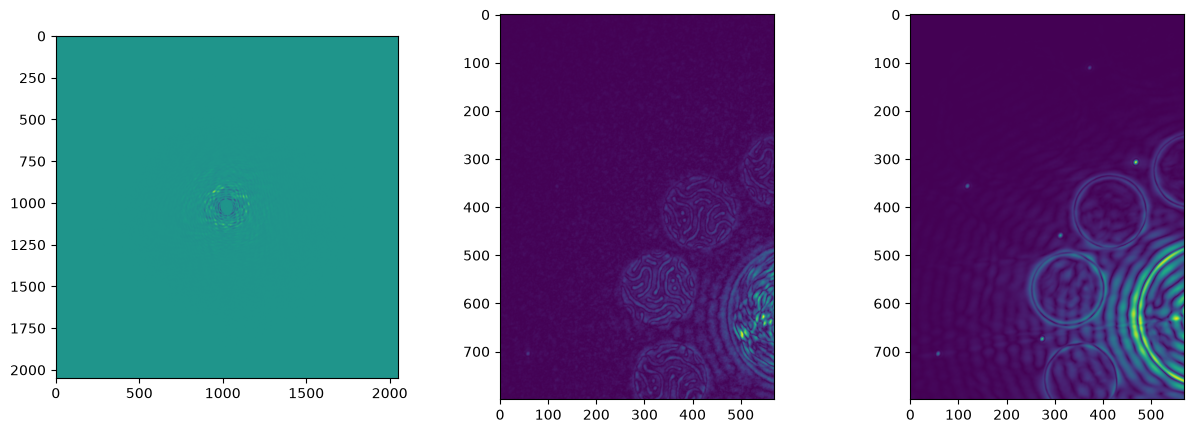

In [15]:
plt.close("all")
%matplotlib inline
fig,ax=plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(holograms[1]-holograms[0])
ax[1].imshow(np.abs(fth.reconstruct(holograms[1]-holograms[0]))[400:1200,400:970])
ax[2].imshow(np.abs(fth.reconstruct(holograms[1]+holograms[0]))[400:1200,400:970])

/tmp/ipykernel_325942/3148378151.py:6: RuntimeWarning: divide by zero encountered in log10
  ax[i,0].imshow(np.log10(np.abs(fields[j,i]-fields[k,i])))
/tmp/ipykernel_325942/3148378151.py:7: RuntimeWarning: divide by zero encountered in log10
  ax[i,1].imshow(np.log10(np.abs(fth.reconstruct((fields[j,i]-fields[k,i])))))


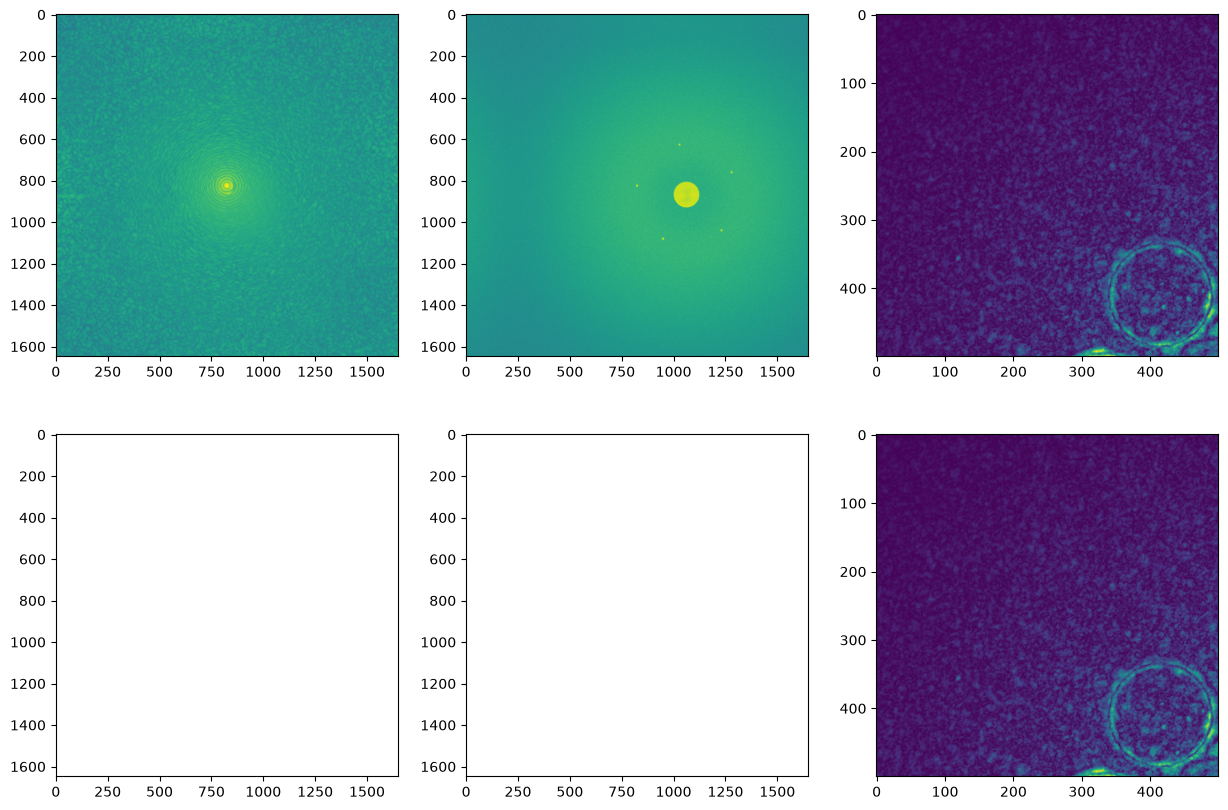

In [16]:
j,k=5,0

if fields.ndim==4:
    fig,ax=plt.subplots(2,3,figsize=(15,10))
    for i in range(2):
        ax[i,0].imshow(np.log10(np.abs(fields[j,i]-fields[k,i])))
        ax[i,1].imshow(np.log10(np.abs(fth.reconstruct((fields[j,i]-fields[k,i])))))
        ax[i,2].imshow(np.abs(fth.reconstruct(holograms[j]-holograms[k]))[400:900,400:900])
else:
    fig,ax=plt.subplots(1,3,figsize=(15,5))
    ax[0].imshow(np.log10(np.abs(fields[j]-fields[k])))
    ax[1].imshow(np.log10(np.abs(fth.reconstruct((fields[j]-fields[k])))))
    ax[2].imshow(np.abs(fth.reconstruct(holograms[j]-holograms[k]))[400:900,400:900])

In [17]:
fields.ndim==4

True

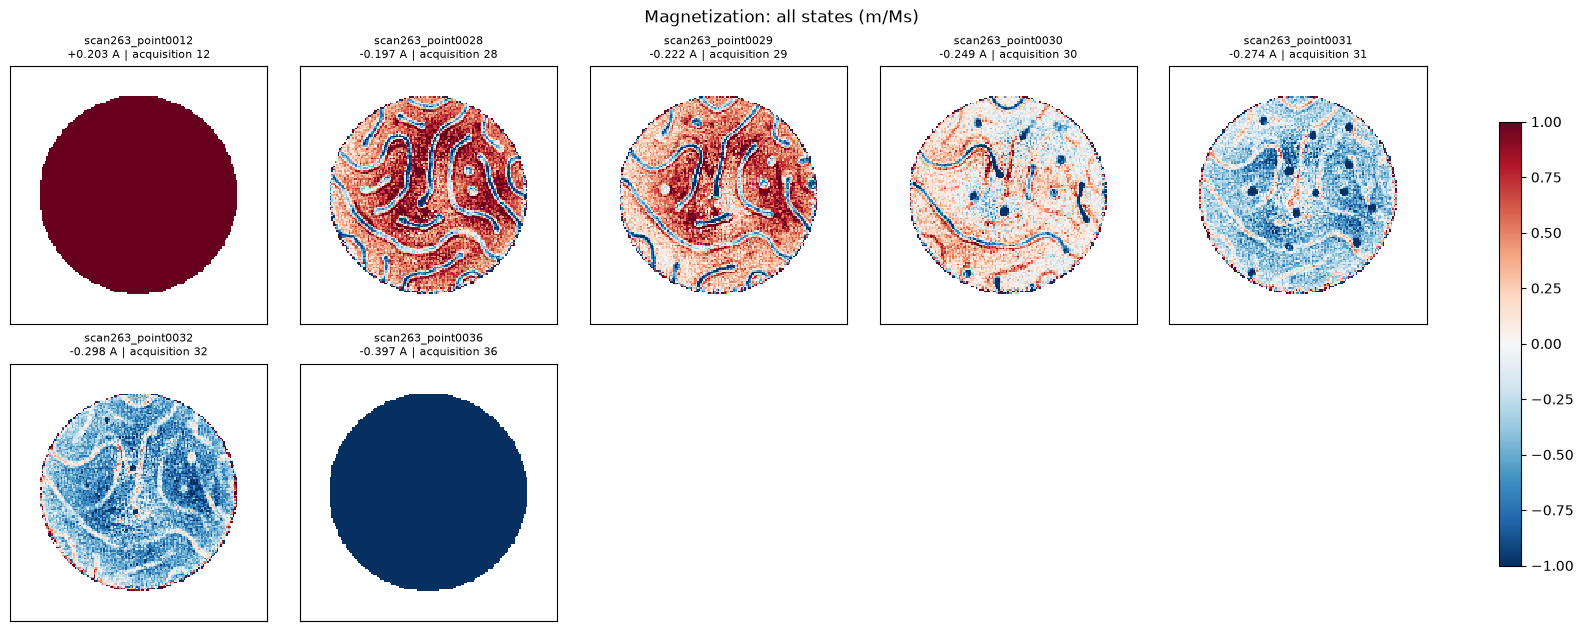

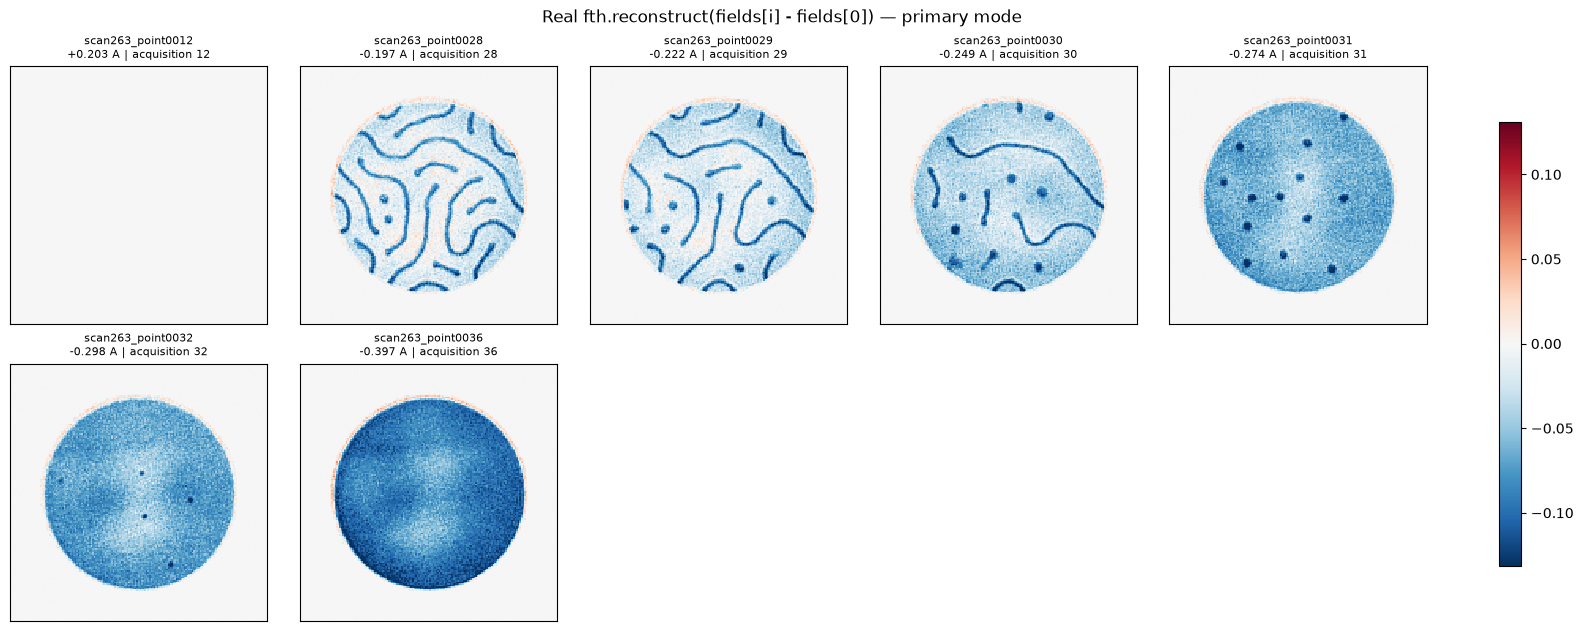

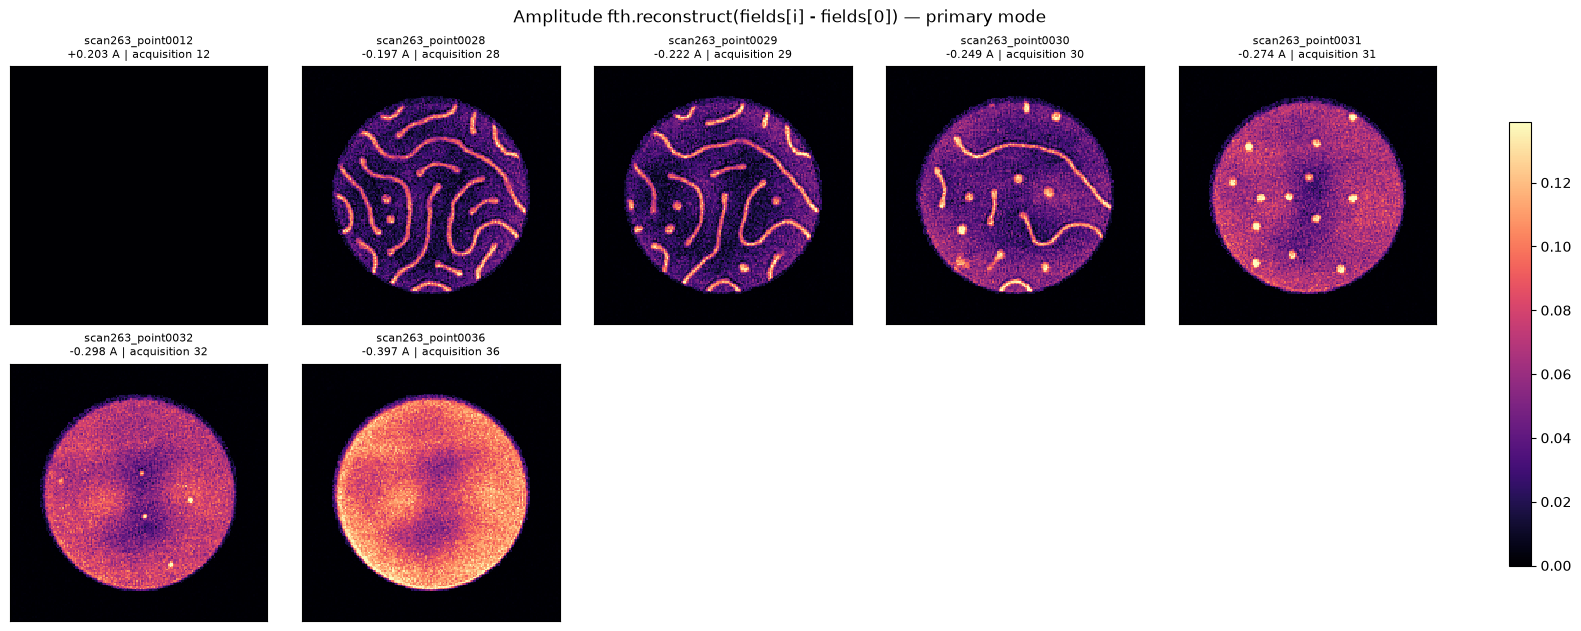

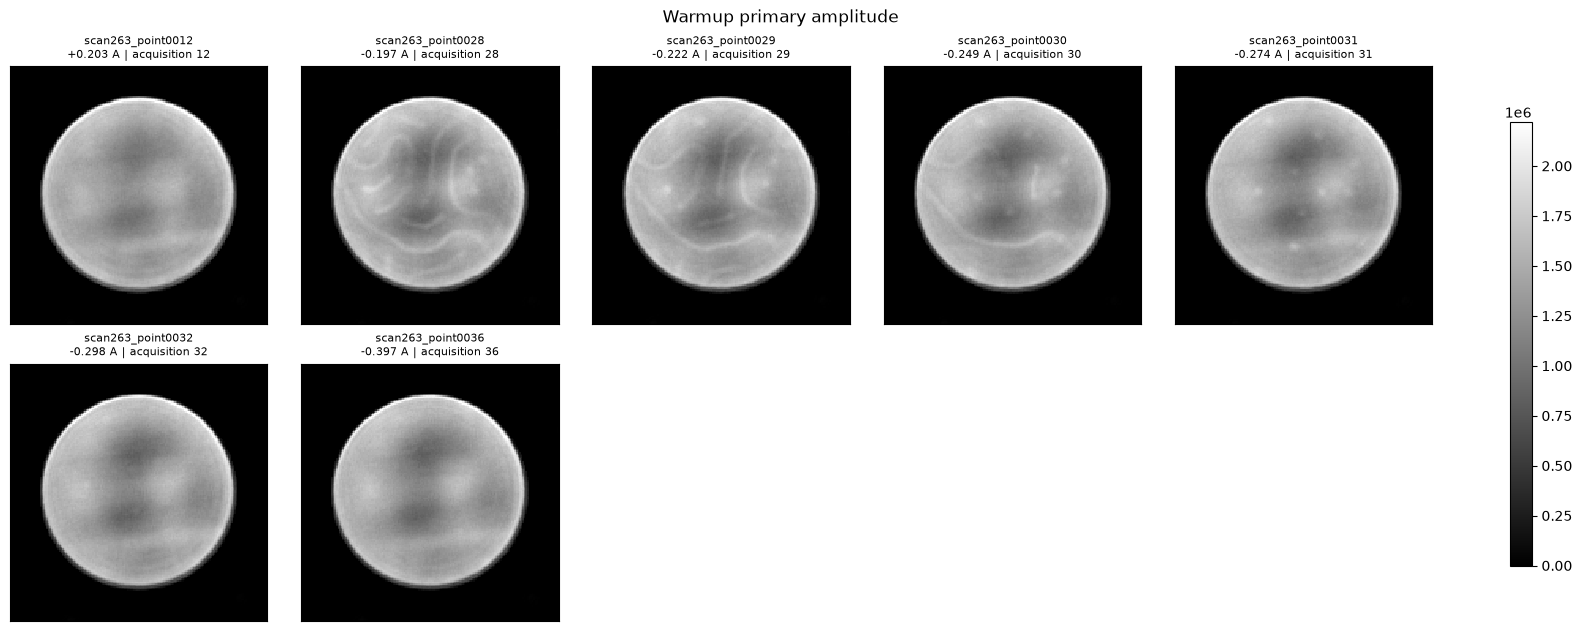

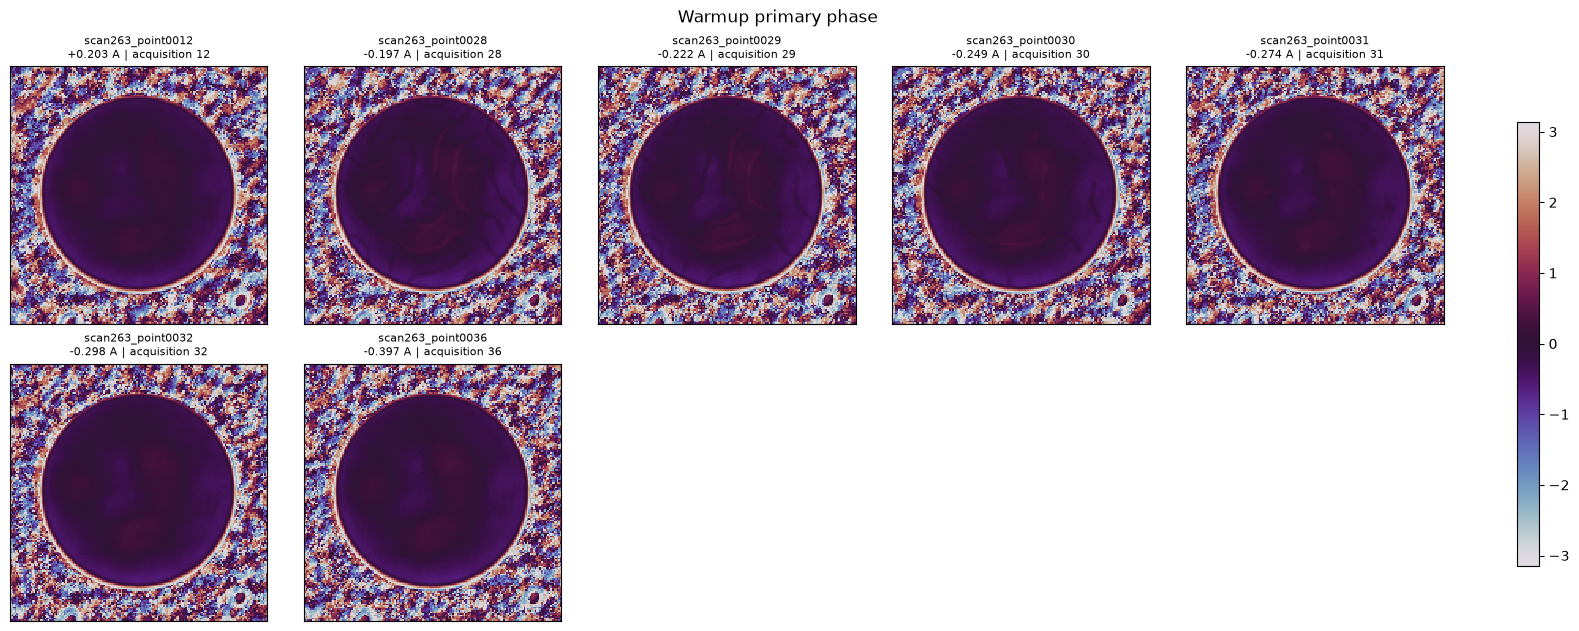

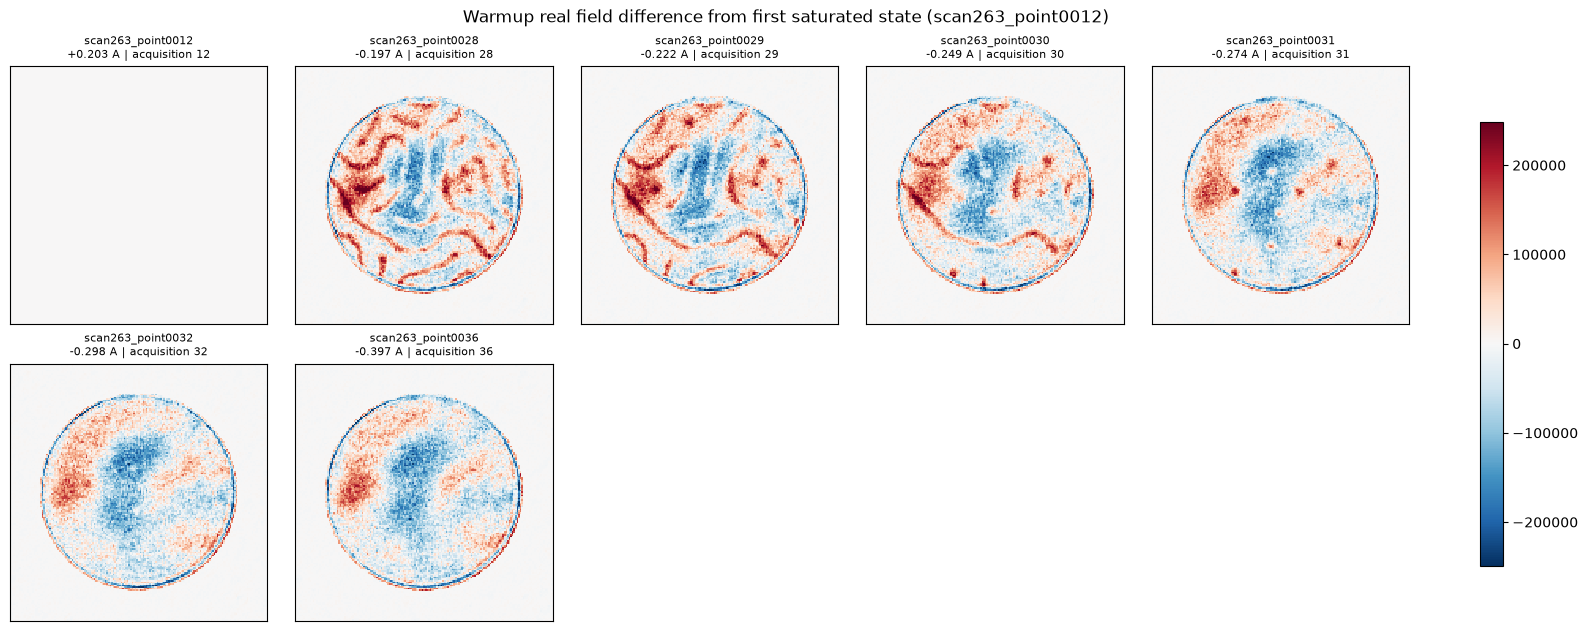

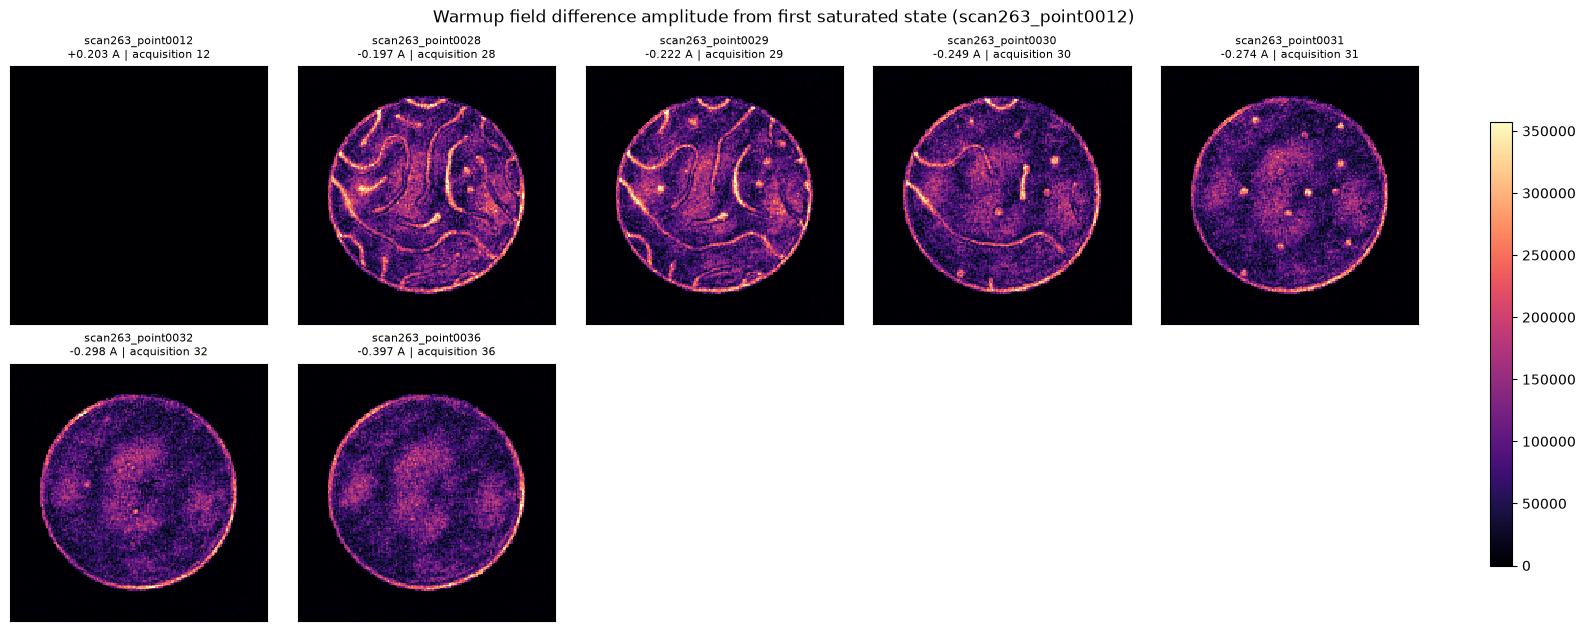

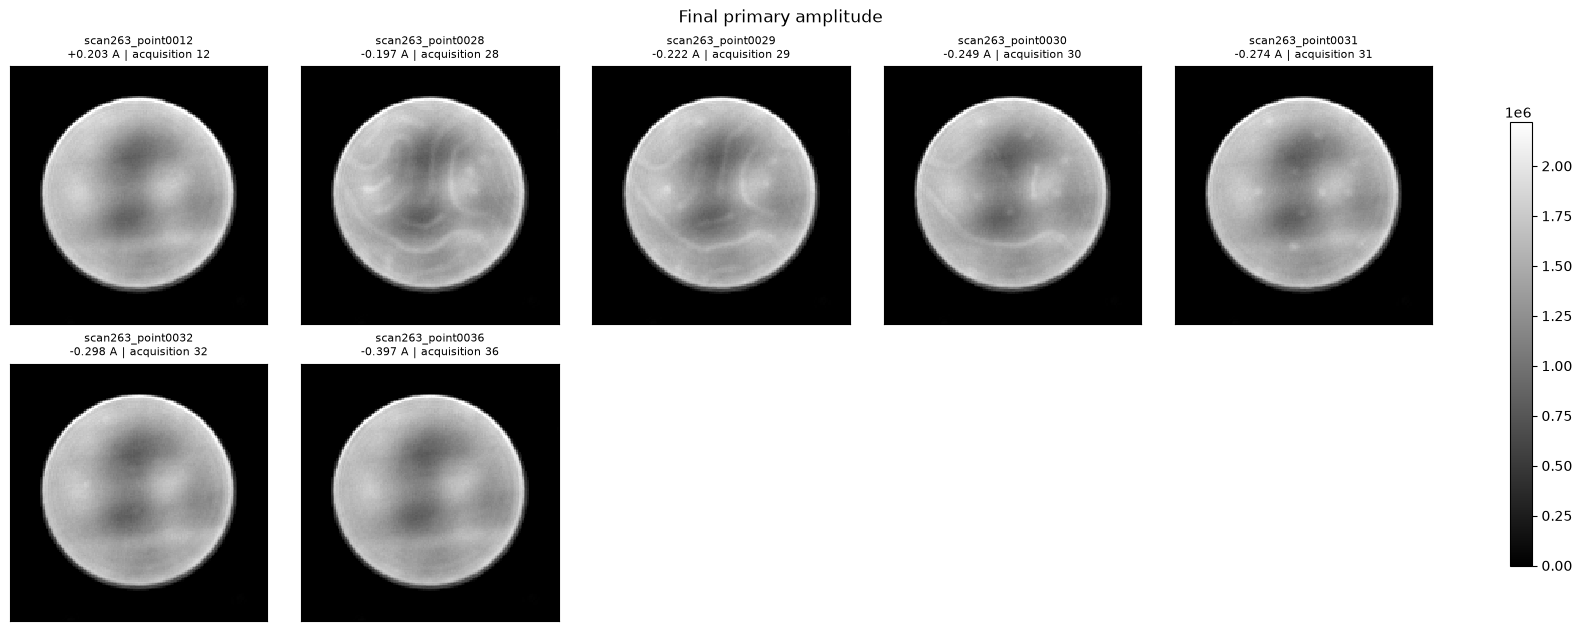

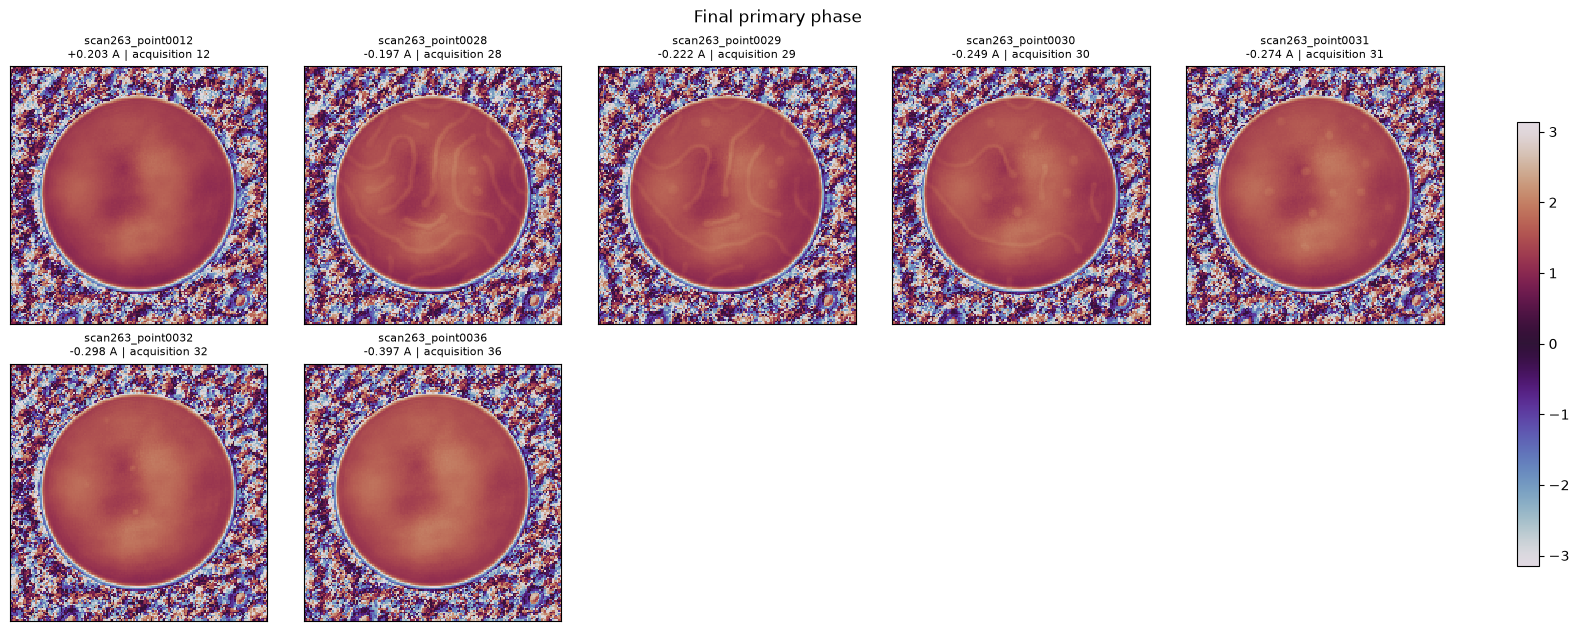

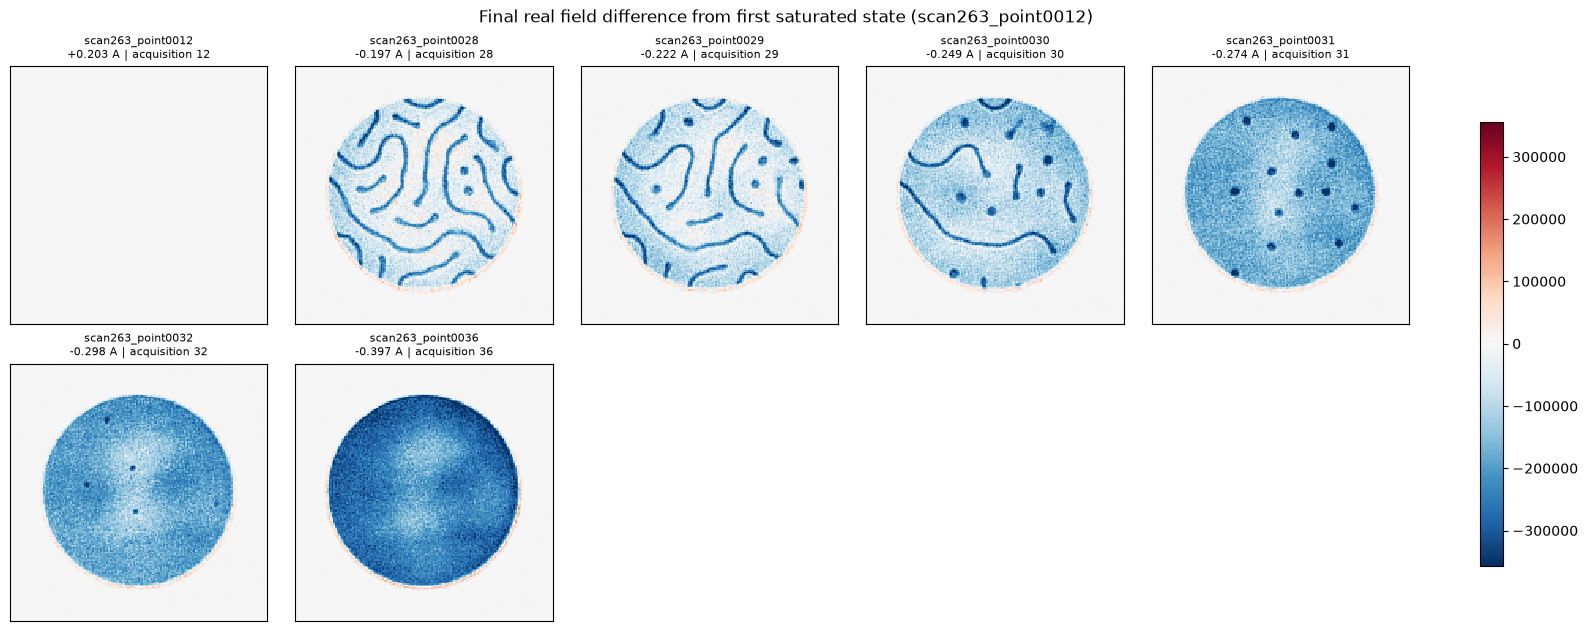

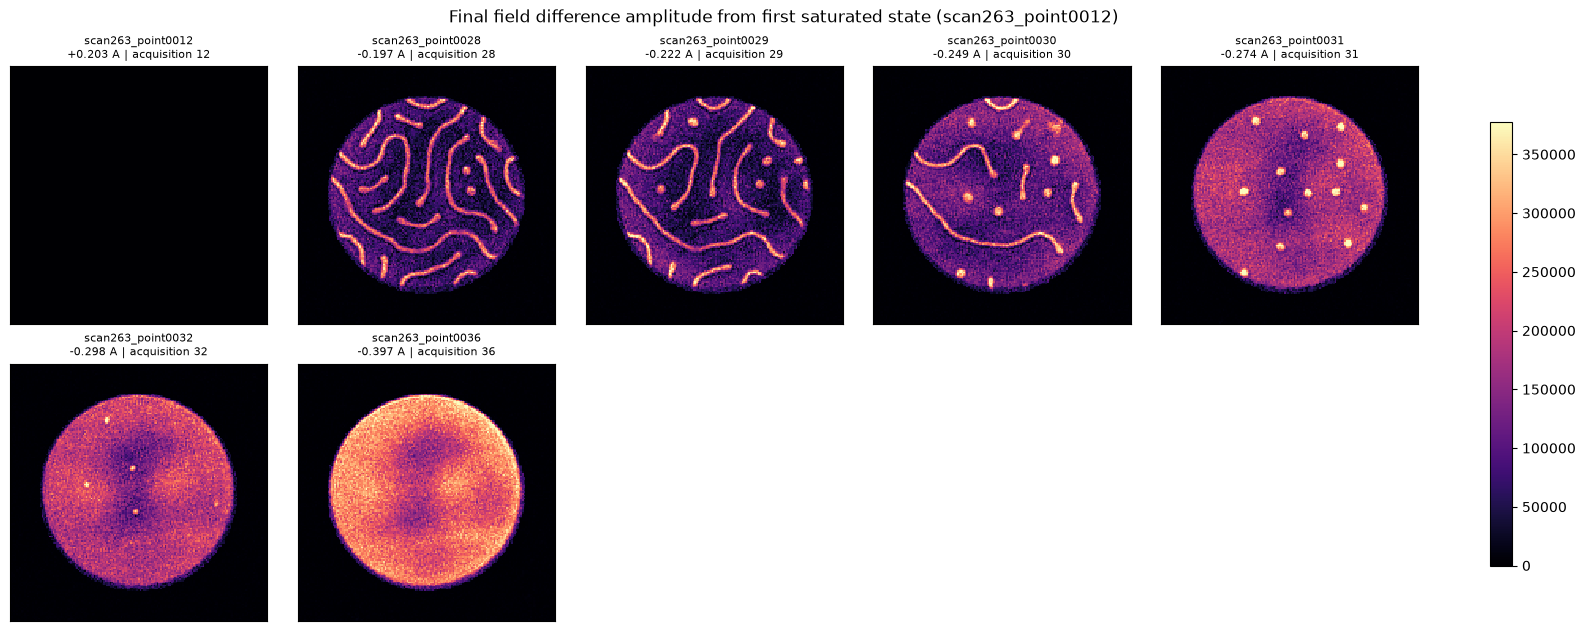

Aperture shared-charge model relative error: 1.4152862767635843
Secondary-mode state dependence (expected near zero only when common): 0.0


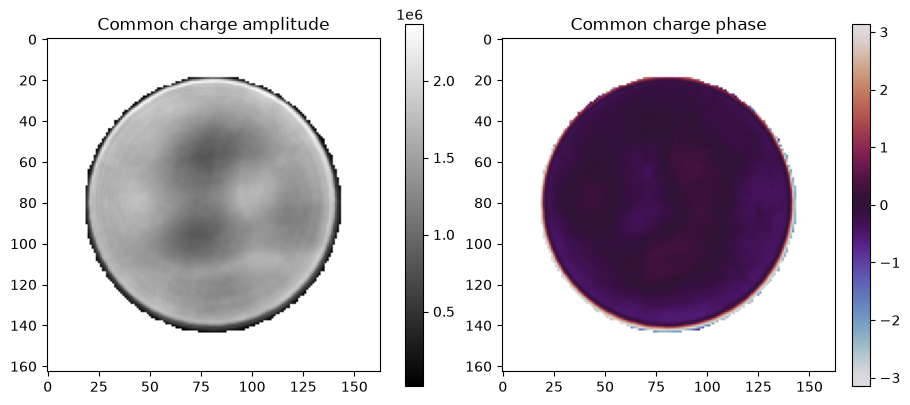

In [19]:
# All spatial maps below use the returned retrieval grid.
def mode_stack(value):
    array = np.asarray(value)
    if array.ndim == 3: return array[:, None]
    if array.ndim == 4: return array
    raise ValueError('Expected (states,y,x) or (states,modes,y,x) fields')

def display_objects(primary_fields):
    focused = universal._projection_focus_transform(
        primary_fields, [ENERGY_EV]*len(primary_fields), recipe['projection_focus_prop_um'],
        recipe['projection_focus_phase_rad'], recipe['projection_focus_setup'])
    return universal.fourier_field_to_display_object(focused)

FIGURES.mkdir(parents=True, exist_ok=True)
warm_modes, final_modes = mode_stack(warmup), mode_stack(fields)*np.exp(1j*np.pi/2)
nstates = len(final_modes)
if len(state_labels) != nstates: raise ValueError('Field/state-label count mismatch')
# Explicitly reorder fitted state maps to the observation order.
state_order = [list(components['state_names']).index(label) for label in state_labels]
magnetization = np.fft.fftshift(np.asarray(components['magnetization'])[state_order], axes=(-2,-1))
thickness_used = np.fft.fftshift(np.asarray(components['material_thickness']))
material_used = thickness_used > 0
support_used = np.asarray(components['supportmask_used'])
if support_used.ndim == 3: support_used = support_used[0]
# Exclude the entire object-hole component, including interpolation edge pixels.
reference_mask = (support_used != 0) & ~universal.largest_support_component(support_used) & ~material_used
roi = geometry.support_bounding_roi(material_used, padding_fraction=.15)
warm_objects = display_objects(warm_modes[:,0])
final_objects = display_objects(final_modes[:,0])

def finite_limit(values, percentile=99.5):
    values = np.abs(np.asarray(values)); values = values[np.isfinite(values)]
    return max(float(np.percentile(values, percentile)), 1e-30) if values.size else 1.

def state_grid(images, title, filename, *, crop=roi, cmap='RdBu_r', vmin=None, vmax=None):
    # All states, in acquisition order, with one color scale for the entire grid.
    columns = min(5, nstates); rows = (nstates + columns - 1)//columns
    fig, axes = plt.subplots(rows, columns, figsize=(3.2*columns, 3.1*rows),
                             squeeze=False, layout='constrained')
    for i, ax in enumerate(axes.flat):
        if i >= nstates:
            ax.set_visible(False); continue
        plane = images[i] if crop is None else images[i][crop]
        im = ax.imshow(np.ma.masked_invalid(plane), cmap=cmap, vmin=vmin, vmax=vmax,
                       origin='upper', interpolation='nearest')
        ax.set_title(f'{state_labels[i]}\n{current[i]:+.3f} A | acquisition {indices[i]}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title)
    fig.colorbar(im, ax=[ax for ax in axes.flat if ax.get_visible()], shrink=.8)
    fig.savefig(FIGURES/filename, dpi=150)
    plt.show(); plt.close(fig)
    return fig

state_grid(np.where(material_used[None], magnetization, np.nan),
           'Magnetization: all states (m/Ms)', 'magnetization_maps.png', crop=roi,
           vmin=-1 if CLIP_MAGNETIZATION else -finite_limit(magnetization, 100),
           vmax=1 if CLIP_MAGNETIZATION else finite_limit(magnetization, 100))

# Exactly the requested transform: subtract detector fields BEFORE fth.reconstruct.
# Call per 2D image: fth.reconstruct shifts all axes of its argument.
# No phase alignment, focusing, intensity subtraction or mode summation here.
fth_differences = np.stack([fth.reconstruct(f[0] - final_modes[0,0]) for f in final_modes])
# Map the aperture from the display FFT convention into fth.reconstruct's
# inverse-FFT convention, including the odd-grid shift.
aperture_field = np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(material_used.astype(float))))
fth_aperture = abs(fth.reconstruct(aperture_field)) > (.5 / material_used.size)
fth_roi = geometry.support_bounding_roi(fth_aperture, padding_fraction=.15)
difference_limit = finite_limit(fth_differences.real[:,fth_aperture])
state_grid(fth_differences.real, 'Real fth.reconstruct(fields[i] - fields[0]) — primary mode',
           'fth_field_differences_real.png', crop=fth_roi, vmin=-difference_limit, vmax=difference_limit)
state_grid(abs(fth_differences), 'Amplitude fth.reconstruct(fields[i] - fields[0]) — primary mode',
           'fth_field_differences_amplitude.png', crop=fth_roi, cmap='magma', vmin=0, vmax=finite_limit(fth_differences[:,fth_aperture]))

amp_limit = finite_limit(np.r_[abs(warm_objects[:,material_used]).ravel(), abs(final_objects[:,material_used]).ravel()])
for name, objects in [('warmup',warm_objects), ('final',final_objects)]:
    state_grid(abs(objects), f'{name.capitalize()} primary amplitude', f'{name}_amplitude.png',
               crop=roi, cmap='gray', vmin=0, vmax=amp_limit)
    state_grid(np.angle(objects), f'{name.capitalize()} primary phase', f'{name}_phase.png',
               crop=roi, cmap='twilight', vmin=-np.pi, vmax=np.pi)
    # Subtract complex fields before taking real part or amplitude.
    object_differences = objects - objects[:1]
    delta_limit = finite_limit(object_differences.real[:,material_used])
    state_grid(object_differences.real,
               f'{name.capitalize()} real field difference from first saturated state ({state_labels[0]})',
               f'{name}_field_difference_real.png', vmin=-delta_limit, vmax=delta_limit)
    state_grid(abs(object_differences),
               f'{name.capitalize()} field difference amplitude from first saturated state ({state_labels[0]})',
               f'{name}_field_difference_amplitude.png', cmap='magma', vmin=0,
               vmax=finite_limit(object_differences[:,material_used]))

charge_log = np.asarray(components['common_log_objects'])[0] + np.asarray(components['material_thickness'])*components['charge_response'][0]
charge_exit_wave = np.where(material_used, np.fft.fftshift(np.exp(charge_log)), np.nan+1j*np.nan)
magnetic_log = thickness_used[None]*components['magnetic_response'][0]*magnetization
model_objects = charge_exit_wave[None]*np.exp(magnetic_log)
model_relative_error = np.linalg.norm((final_objects-model_objects)[:,material_used])/max(np.linalg.norm(model_objects[:,material_used]),1e-30)
secondary_relative_error = (np.linalg.norm(final_modes[:,1:]-final_modes[:1,1:])/max(np.linalg.norm(final_modes[:,1:]),1e-30)
                            if final_modes.shape[1] > 1 else 0.)
# Diagnostics report mismatches without blocking the remaining figures or export.
print('Aperture shared-charge model relative error:', model_relative_error)
if final_modes.shape[1] > 1:
    print('Secondary-mode state dependence (expected near zero only when common):', secondary_relative_error)
fig, axes = plt.subplots(1,2,figsize=(9,4),layout='constrained')
for ax, image, title, cmap in zip(axes, [abs(charge_exit_wave),np.angle(charge_exit_wave)],
                                ['Common charge amplitude','Common charge phase'], ['gray','twilight']):
    im=ax.imshow(np.ma.masked_invalid(image[roi]),cmap=cmap)
    ax.set_title(title); fig.colorbar(im,ax=ax)
fig.savefig(FIGURES/'common_charge.png',dpi=150);plt.show();plt.close(fig)


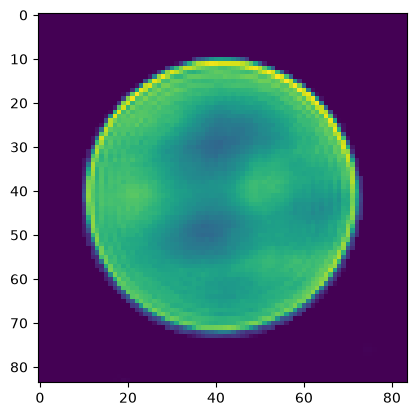

In [32]:
fig,ax=plt.subplots()
ax.imshow(np.abs(final_objects[0][roi]))

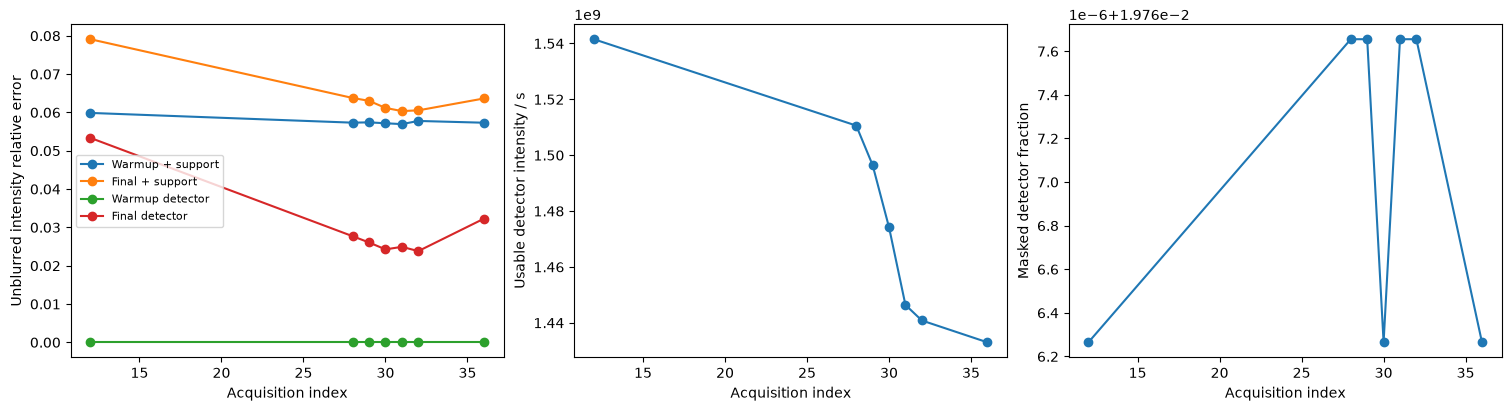

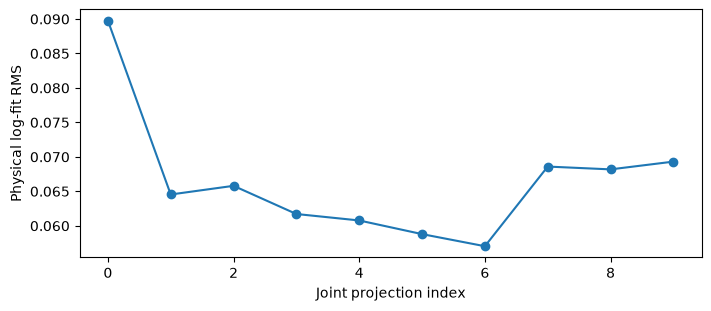

In [33]:
# Reproduce the solver's detector crop/binning before comparing with returned fields.
diagnostic_holograms, diagnostic_masks, _, _, _ = geometry.prepare(
    holograms, mask_pixel, support, recipe)
diagnostic_masks = np.broadcast_to(np.asarray(bsmasks, bool), diagnostic_holograms.shape)
modal_support = np.asarray(components['modal_supportmask_used'])
if modal_support.ndim == 2: modal_support = modal_support[None]

def compatibility(stack, apply_support=True):
    values=[]
    for i, modes in enumerate(mode_stack(stack)):
        if apply_support:
            objects=np.fft.fftshift(np.fft.fft2(np.fft.fftshift(modes,axes=(-2,-1))),axes=(-2,-1))
            objects *= modal_support
            modes=np.fft.ifftshift(np.fft.ifft2(np.fft.ifftshift(objects,axes=(-2,-1))),axes=(-2,-1))
        prediction=np.sum(abs(modes)**2,axis=0)
        valid=(~diagnostic_masks[i]) & np.isfinite(diagnostic_holograms[i]) & np.isfinite(prediction)
        norm=np.linalg.norm(diagnostic_holograms[i][valid])
        values.append(np.linalg.norm((prediction-diagnostic_holograms[i])[valid])/norm if norm > 0 else np.nan)
    return np.asarray(values)

warm_error, final_error = compatibility(warmup), compatibility(fields)
warm_detector_error, final_detector_error = compatibility(warmup,False), compatibility(fields,False)
fig,axes=plt.subplots(1,3,figsize=(15,4),layout='constrained')
for values,label in [(warm_error,'Warmup + support'),(final_error,'Final + support'),
                     (warm_detector_error,'Warmup detector'),(final_detector_error,'Final detector')]:
    axes[0].plot(indices,values,'o-',label=label)
axes[0].set(xlabel='Acquisition index',ylabel='Unblurred intensity relative error');axes[0].legend(fontsize=8)
axes[1].plot(indices,np.sum(np.where(diagnostic_masks,0,diagnostic_holograms),axis=(-2,-1)),'o-')
axes[1].set(xlabel='Acquisition index',ylabel='Usable detector intensity / s')
axes[2].plot(indices,diagnostic_masks.mean(axis=(-2,-1)),'o-')
axes[2].set(xlabel='Acquisition index',ylabel='Masked detector fraction')
fig.savefig(FIGURES/'data_diagnostics.png',dpi=150);plt.show();plt.close(fig)
if components.get('partial_coherence',False):
    print('Intensity errors above are unblurred diagnostics; they do not include the coherence kernel.')
projection_steps=errors.get('projection_steps',[])
if projection_steps:
    fig,ax=plt.subplots(figsize=(7,3),layout='constrained')
    ax.plot([step['fit_residual_rms'] for step in projection_steps],'o-')
    ax.set(xlabel='Joint projection index',ylabel='Physical log-fit RMS')
    fig.savefig(FIGURES/'physical_fit_history.png',dpi=150);plt.show();plt.close(fig)


Endpoint estimate unavailable: no reference-hole pixels on retrieval grid.
Endpoint estimate unavailable: no reference-hole pixels on retrieval grid.


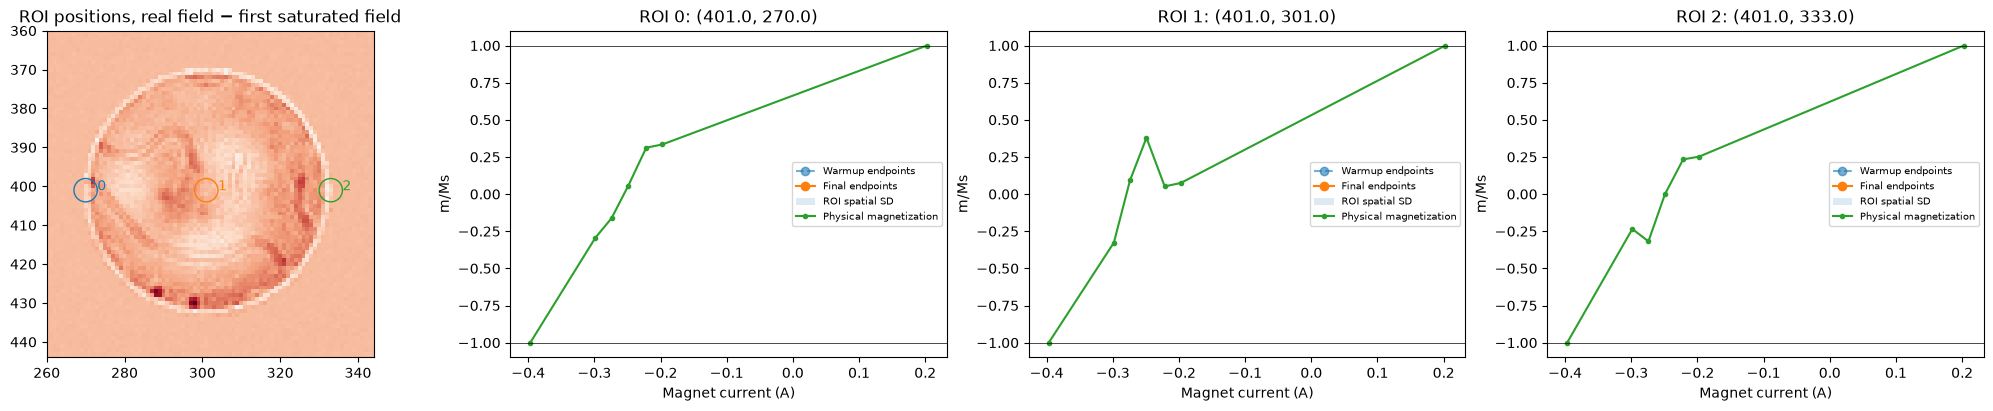

Interior ROI endpoint/model RMS: unavailable
Endpoint estimates are unclipped; saturated endpoints are calibration, not validation.
ROI bands show spatial variation, not statistical confidence intervals.


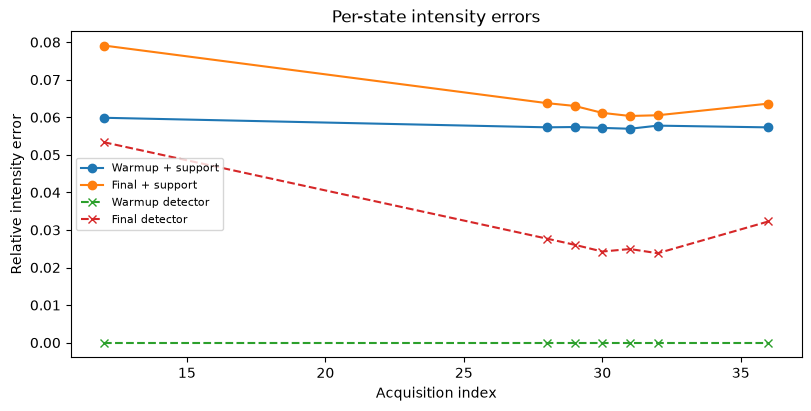

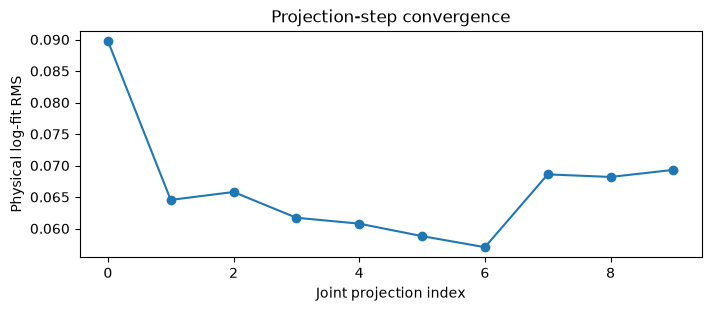

In [34]:
# Optional endpoint estimates: unavailable reference/contrast gives NaNs, not a failed plot cell.
def endpoint_diagnostic(objects):
    try:
        # If reference_mask isn't available, skip rather than crash.
        if 'reference_mask' not in globals() and 'reference_mask' not in locals():
            print('Reference mask missing; skipping endpoint diagnostic.')
            return np.full(objects.shape,np.nan), np.zeros(material_used.shape,bool), np.full(objects.shape,np.nan)
        if not np.any(reference_mask):
            print('Endpoint estimate unavailable: no reference-hole pixels on retrieval grid.')
            return np.full(objects.shape,np.nan), np.zeros(material_used.shape,bool), np.full(objects.shape,np.nan)
        return inputs.endpoint_magnetization(objects,positive,negative,material_used,reference_mask)
    except Exception as e:
        print('Endpoint diagnostic failed:',e);
        return np.full(objects.shape,np.nan), np.zeros(material_used.shape,bool), np.full(objects.shape,np.nan)

warm_m,warm_valid,warm_log_residual=endpoint_diagnostic(warm_objects)
final_m,final_valid,final_log_residual=endpoint_diagnostic(final_objects)
yy,xx=np.nonzero(material_used)
# Robustly pick ROI centers (fall back to image center if no material pixels).
if yy.size == 0:
    print('No material pixels found; using image centre for ROI.')
    cy,cx = np.array(material_used.shape)/2.0; centers=[(float(cy),float(cx))]
else:
    if ROI_CENTERS is None:
        cy,cx=float(np.mean(yy)),float(np.mean(xx)); width=float(np.ptp(xx)) if np.ptp(xx)!=0 else float(material_used.shape[1])
        centers=[]
        for target in [cx-width*.2,cx,cx+width*.2]:
            nearest=np.argmin((yy-cy)**2+(xx-target)**2)
            centers.append((float(yy[nearest]),float(xx[nearest])))
    else: centers=list(ROI_CENTERS)

# Ensure ROI_RADIUS is sensible
try:
    ROI_RADIUS = max(1, int(ROI_RADIUS))
except Exception:
    ROI_RADIUS = 3

def diagnostic_curves(maps, valid):
    rows,cols=np.indices(material_used.shape)
    means=np.full((len(centers),nstates),np.nan)
    spreads=means.copy(); masks=[]
    for j,(cy,cx) in enumerate(centers):
        mask=((rows-cy)**2+(cols-cx)**2<=ROI_RADIUS**2)&material_used
        masks.append(mask)
        for i in range(nstates):
            values=maps[i][mask & valid & np.isfinite(maps[i])]
            if values.size:
                means[j,i]=np.mean(values)
                spreads[j,i]=np.std(values)
    return means,spreads,np.asarray(masks)

fit_curves,fit_spread,roi_masks=diagnostic_curves(magnetization,material_used)
warm_curves,warm_spread,_=diagnostic_curves(warm_m,warm_valid)
final_curves,final_spread,_=diagnostic_curves(final_m,final_valid)
# Create figure with at least one column even if no centers detected
ncols = max(1, len(centers)+1)
fig,axes=plt.subplots(1,ncols,figsize=(5*ncols,4),squeeze=False,layout='constrained')
axes=axes[0]
# Try to show a preview of the object; don't crash if it fails
try: axes[0].imshow((final_objects[nstates//2]-final_objects[0]).real,cmap='RdBu_r')
except Exception:
    axes[0].text(0.5,0.5,'Unable to show object preview',ha='center',va='center')
for j,(cy,cx) in enumerate(centers):
    color=f'C{j%10}'
    try: axes[0].add_patch(plt.Circle((cx,cy),ROI_RADIUS,fill=False,color=color))
    except Exception: pass
    try: axes[0].text(cx+ROI_RADIUS,cy,str(j),color=color)
    except Exception: pass
    ax = axes[j+1] if j+1 < len(axes) else plt.gca()
    ax.plot(current, np.asarray(warm_curves[j]), 'o--', label='Warmup endpoints', alpha=.6)
    ax.plot(current, np.asarray(final_curves[j]), 'o-', label='Final endpoints')
    # shaded ROI spatial SD (guard lengths)
    try:
        ax.fill_between(current, np.asarray(final_curves[j])-np.asarray(final_spread[j]), np.asarray(final_curves[j])+np.asarray(final_spread[j]), alpha=.15, label='ROI spatial SD')
    except Exception: pass
    ax.plot(current, np.asarray(fit_curves[j]), '.-', label='Physical magnetization')
    ax.axhline(1,color='k',lw=.5);ax.axhline(-1,color='k',lw=.5)
    ax.set(xlabel='Magnet current (A)',ylabel='m/Ms',title=f'ROI {j}: ({cy:.1f}, {cx:.1f})');ax.legend(fontsize=7)
axes[0].set_title('ROI positions, real field − first saturated field')
# Respect roi bounding box ordering when setting limits; guard missing roi
try:
    axes[0].set_xlim(roi[1].start,roi[1].stop);axes[0].set_ylim(roi[0].stop,roi[0].start)
except Exception: pass
fig.savefig(FIGURES/'local_hysteresis.png',dpi=150);plt.show();plt.close(fig)
# Agreement between final endpoint estimates and fitted physical curve (interior states)
interior=np.array([s not in saturated for s in state_labels])
try:
    agreement=(final_curves[:,interior]-fit_curves[:,interior]).ravel()
    agreement=agreement[np.isfinite(agreement)]
    print('Interior ROI endpoint/model RMS:',np.sqrt(np.mean(agreement**2)) if agreement.size else 'unavailable')
except Exception as e: print('Agreement calculation failed:',e)
print('Endpoint estimates are unclipped; saturated endpoints are calibration, not validation.')
print('ROI bands show spatial variation, not statistical confidence intervals.')

# Additional diagnostics: per-state errors and per-projection-step convergence
try:
    fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
    if 'warm_error' in globals() and 'final_error' in globals():
        ax.plot(indices,warm_error,'o-',label='Warmup + support')
        ax.plot(indices,final_error,'o-',label='Final + support')
    if 'warm_detector_error' in globals() and 'final_detector_error' in globals():
        ax.plot(indices,warm_detector_error,'x--',label='Warmup detector')
        ax.plot(indices,final_detector_error,'x--',label='Final detector')
    ax.set(xlabel='Acquisition index',ylabel='Relative intensity error',title='Per-state intensity errors')
    ax.legend(fontsize=8)
    fig.savefig(FIGURES/'per_state_intensity_errors.png',dpi=150);plt.show();plt.close(fig)
except Exception as e: print('Per-state error plot failed:',e)

# Projection-step convergence (physical fit history)
projection_steps = errors.get('projection_steps',[]) if isinstance(errors,dict) else []
if projection_steps:
    try:
        fig,ax=plt.subplots(figsize=(7,3),layout='constrained')
        ax.plot([step.get('fit_residual_rms',np.nan) for step in projection_steps],'o-')
        ax.set(xlabel='Joint projection index',ylabel='Physical log-fit RMS',title='Projection-step convergence')
        fig.savefig(FIGURES/'physical_fit_history.png',dpi=150);plt.show();plt.close(fig)
    except Exception as e: print('Projection-step convergence plot failed:',e)
# Per-state projection history if present in errors dict
per_state_hist = errors.get('per_state_projection_history') if isinstance(errors,dict) else None
if per_state_hist:
    try:
        fig,ax=plt.subplots(figsize=(8,4),layout='constrained')
        for i, series in enumerate(per_state_hist):
            ax.plot(series,label=f'state {i}')
        ax.set(xlabel='Projection step',ylabel='Metric',title='Per-state projection history')
        ax.legend(fontsize=6)
        fig.savefig(FIGURES/'per_state_projection_history.png',dpi=150);plt.show();plt.close(fig)
    except Exception as e: print('Per-state projection history plot failed:',e)


In [35]:
def save_tree(group,values):
    for key,value in values.items():
        name=str(key)
        if isinstance(value,dict): save_tree(group.create_group(name),value)
        elif value is None: group.attrs[name]='None'
        else:
            try:
                array=np.asarray(value)
                if array.dtype.kind in 'biufc': group.create_dataset(name,data=array)
                else: group.attrs[name]=json.dumps(value,default=lambda x:np.asarray(x).tolist())
            except (TypeError,ValueError): group.attrs[name]=str(value)
OUTPUT.parent.mkdir(parents=True,exist_ok=True)
temporary_output=OUTPUT.with_suffix('.tmp.h5')
with h5py.File(temporary_output,'w') as h:
    h.attrs['preprocessing_json']=json.dumps(config)
    h.attrs['saturated_states_json']=json.dumps(saturated)
    h.attrs['recipe_json']=json.dumps(recipe,default=lambda x:np.asarray(x).tolist())
    h.attrs['magnetization_units']='m/Ms conditional on saturation anchors; no absolute A/m calibration'
    h.attrs['component_stage']='Final physical projection; components describe returned primary fields only where thickness is nonzero'
    h.create_dataset('state_labels',data=np.asarray(state_labels,dtype=h5py.string_dtype()))
    for name,value in dict(current_A=current,selected_indices=indices,fields=fields,warmup_fields=warmup,
        supportmask=support_used,material_mask=material_used,mask_pixel=bsmasks,holograms=diagnostic_holograms,
        fth_field_differences=fth_differences,
        charge_exit_wave=charge_exit_wave,magnetic_log=magnetic_log,
        magnetization=magnetization,warmup_endpoint_m=warm_m,final_endpoint_m=final_m,
        warmup_endpoint_valid=warm_valid,final_endpoint_valid=final_valid,
        warmup_log_residual=warm_log_residual,final_log_residual=final_log_residual,
        roi_centers=centers,roi_masks=roi_masks,fit_roi_curves=fit_curves,
        warmup_roi_curves=warm_curves,final_roi_curves=final_curves,final_roi_spread=final_spread,
        warmup_support_error=warm_error,final_support_error=final_error,
        warmup_detector_error=warm_detector_error,final_detector_error=final_detector_error).items():
        h.create_dataset(name,data=value,compression='gzip')
    save_tree(h.create_group('physical_components'),components)
    save_tree(h.create_group('histories'),errors)
temporary_output.replace(OUTPUT)
np.savetxt(FIGURES/'local_hysteresis.csv',np.column_stack([np.asarray(indices),current,fit_curves.T,warm_curves.T,final_curves.T]),delimiter=',',header=','.join(['acquisition_index','current_A']+[f'{kind}_roi{j}' for kind in ['fit','warmup_endpoint','final_endpoint'] for j in range(len(centers))]),comments='')
print('Saved',OUTPUT,'and diagnostics in',FIGURES)


Saved /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/2601_XPCS/processed/physical_hysteresis_263.h5 and diagnostics in /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/2601_XPCS/processed/physical_hysteresis_263
